<a href="https://colab.research.google.com/github/Tan-Jiahao-CSC/SIT-UofG-QC/blob/main/QC-Lab1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [21]:
%pip install qiskit==1.2.4
%pip install qiskit-aer==0.15.1
%pip install pylatexenc==2.10

from qiskit import QuantumCircuit
from qiskit.converters import circuit_to_gate
from qiskit.visualization import array_to_latex
from qiskit.quantum_info import Operator
from qiskit.quantum_info import Statevector
from qiskit import transpile
from qiskit.providers.basic_provider import BasicSimulator
from qiskit.visualization import plot_histogram

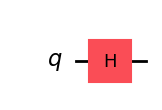

In [22]:

# Create a circuit with one qubit
circuit = QuantumCircuit(1)

# Add a Hadamard (H) gate on qubit 0, to create a superposition
circuit.h(0)

# Draw the circuit diagram. Delete "mpl" to get a text diagram.
circuit.draw("mpl")

In [23]:
# Now simulate the circuit by calculating the effect on state vectors.
# Set the initial state of the simulator to |0>
# The state vector has two coefficients, both 0
state = Statevector.from_int(0, 2)

# Apply the circuit to the state
state = state.evolve(circuit)

# Display using latex. This requires the pylatexenc module.
# Omit "latex" to get a numerical (not algebraic) view of the state vector.
state.draw("latex")

<IPython.core.display.Latex object>

In [24]:
# A different way of dislaying the state, again using latex
from qiskit.visualization import array_to_latex

array_to_latex(state)

<IPython.core.display.Latex object>

In [25]:
# The whole circuit is a unitary operator, which we can display.

U = Operator(circuit)
array_to_latex(U)

<IPython.core.display.Latex object>

In [26]:
# Or less beautifully:
U.data
# The format is a little bit odd. 0.j means the imaginary part is 0
# 0 is being displayed with a decimal point but no trailing 0
# j is used for the square root of -1, instead of i

array([[ 0.70710678+0.j,  0.70710678+0.j],
       [ 0.70710678+0.j, -0.70710678+0.j]])

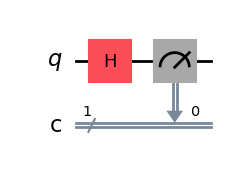

In [27]:
# Now reconstruct the circuit and add a measurement
# The second parameter of QuantumCircuit is the number of classical bits
circuit = QuantumCircuit(1,1)
circuit.h(0)

# The first list is the qubits to measure,
# the second list is the classical bits where the results go
circuit.measure([0],[0])
circuit.draw("mpl")

In [28]:
# We will need to transpile the circuit into QASM instructions for the back end

# Use BasicSimulator
backend = BasicSimulator()

# Compile / transpile
qc_compiled = transpile(circuit, backend)

# Run the circuit on the simulator.
# We've set the number of repeats of the circuit
# to be 1024, which is the default.
# The qubits start in state |0>
job_sim = backend.run(qc_compiled, shots=1024)

# Grab the results from the job (this doesn't produce any output).
result_sim = job_sim.result()

In [29]:
# The simplest way to see the results of the simulation
counts = result_sim.get_counts(qc_compiled)
print(counts)

# The results are not exactly half 0 and half 1, but should be close.
# There will be different results each time the previous cell is run.

{'0': 519, '1': 505}


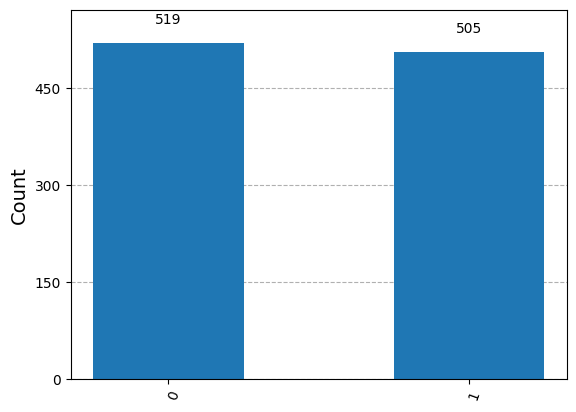

In [30]:
# We can also produce a graph

plot_histogram(counts)

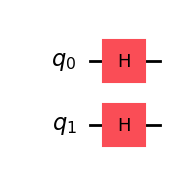

In [31]:
# Now let's move on to two qubits.
# Apply H to both qubits and see what we get.

circuit = QuantumCircuit(2)
circuit.h(0)
circuit.h(1)

circuit.draw("mpl")

In [32]:
state = Statevector.from_int(0, 4) # 4 is the number of basis states on 2 qubits
state = state.evolve(circuit)
state.draw("latex")

<IPython.core.display.Latex object>

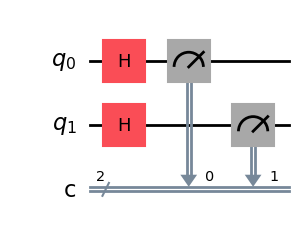

In [33]:
# Now measurement. This time we construct the measurement part
# of the circuit separately and then combine it with the first circuit.

# A new circuit with 2 qubits and 2 classical bits
meas = QuantumCircuit(2, 2)

# Map the quantum measurement to the classical bits
meas.measure(range(2), range(2))

# The Qiskit circuit object supports composition.
# Here the meas has to be first and front=True (putting it before)
# as compose must put a smaller circuit into a larger one.
qc = meas.compose(circuit, range(2), front=True)

qc.draw("mpl")

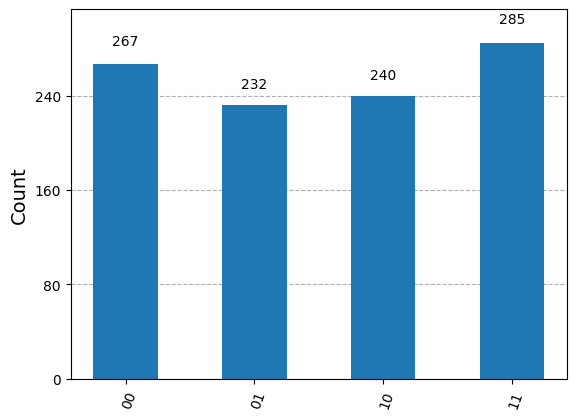

In [34]:
# Simulate again, using the same back end
qc_compiled = transpile(qc, backend)
job_sim = backend.run(qc_compiled, shots=1024)
result_sim = job_sim.result()
counts = result_sim.get_counts(qc_compiled)
plot_histogram(counts)

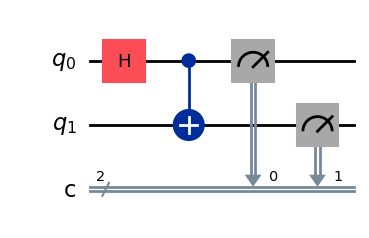

In [35]:
# Now for some entanglement.
# Construct a Bell state and measure both qubits to see that
# both measurements give the same result.

circuit = QuantumCircuit(2,2)
circuit.h(0)
circuit.cx(0,1) # cx means CNOT because it's a controlled version of x (negation)
circuit.measure(range(2),range(2))
circuit.draw("mpl")

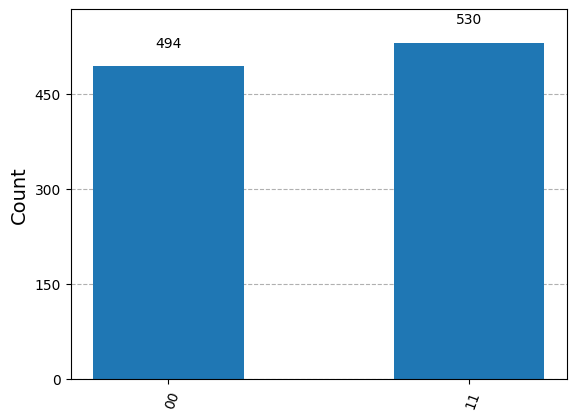

In [36]:
qc_compiled = transpile(circuit, backend)
job_sim = backend.run(qc_compiled, shots=1024)
result_sim = job_sim.result()
counts = result_sim.get_counts(qc_compiled)
plot_histogram(counts)

In [37]:
# EXERCISE

# Make a copy here of the circuit that creates the Bell state 1/sqrt(2) ( |00> + |11> ).

# Modify it to create the other Bell states: 1/sqrt(2) ( |00> - |11> ), 1/sqrt(2) ( |01> + |10> ), 1/sqrt(2) ( |01> - |10> ).

# You will need to use X and Z gates. Check that your circuit is correct by displaying the state vector in each case.

# For each of the Bell states, repeat the simulation with measurements and check that the results are as expected.


Bell State 1: (|00> + |11>) / sqrt(2)


<IPython.core.display.Latex object>

{'00': 549, '11': 475}


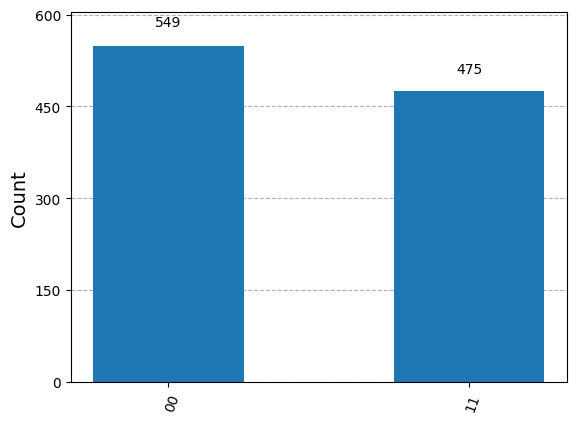

Bell State 2: (|00> - |11>) / sqrt(2)


<IPython.core.display.Latex object>

{'00': 516, '11': 508}


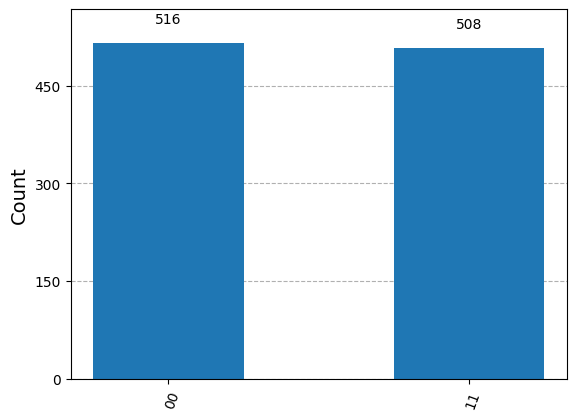

Bell State 3: (|01> + |10>) / sqrt(2)


<IPython.core.display.Latex object>

{'10': 527, '01': 497}


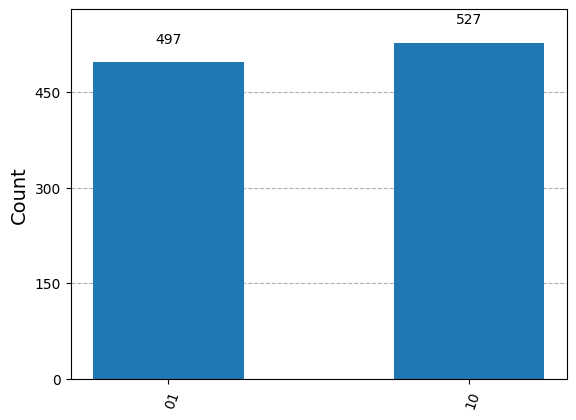

Bell State 4: (|01> - |10>) / sqrt(2)


<IPython.core.display.Latex object>

{'10': 541, '01': 483}


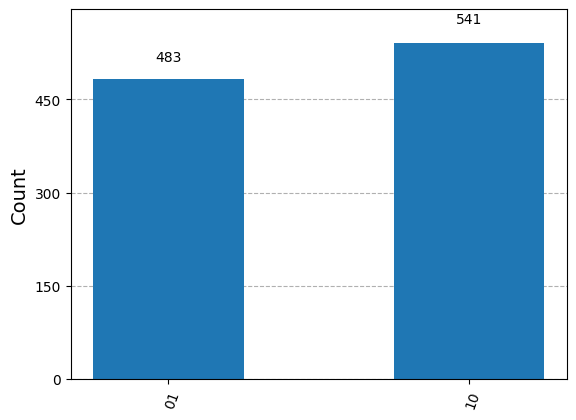

In [38]:
# ============================================================
# EXERCISE 1 — BELL STATES
# ============================================================

# Import required libraries
from qiskit import QuantumCircuit, transpile
from qiskit.quantum_info import Statevector
from qiskit.visualization import plot_histogram
from qiskit.providers.basic_provider import BasicSimulator

# Create the simulator backend
backend = BasicSimulator()

# ------------------------------------------------------------
# Function to:
# 1. Display the statevector
# 2. Measure the qubits
# 3. Simulate the circuit
# 4. Show the measurement results
# ------------------------------------------------------------
def show_state_and_measure(circuit, title):

    # Print the Bell state title
    print(title)

    # --------------------------------------------------------
    # Create the initial quantum state |00>
    # 2 qubits = 4 basis states
    # --------------------------------------------------------
    state = Statevector.from_int(0, 2 ** circuit.num_qubits)

    # Apply the quantum circuit to the statevector
    state = state.evolve(circuit)

    # Display the resulting quantum state in LaTeX format
    display(state.draw("latex"))

    # --------------------------------------------------------
    # Create a new circuit for measurement
    # 2 qubits and 2 classical bits
    # --------------------------------------------------------
    measured = QuantumCircuit(2, 2)

    # Add the Bell-state circuit into the measurement circuit
    measured.compose(circuit, inplace=True)

    # Measure both qubits
    # Qubit 0 -> Classical bit 0
    # Qubit 1 -> Classical bit 1
    measured.measure(range(2), range(2))

    # Compile the circuit for the simulator
    qc_compiled = transpile(measured, backend)

    # Run the simulation 1024 times
    job_sim = backend.run(qc_compiled, shots=1024)

    # Get the simulation results
    result_sim = job_sim.result()

    # Count the measurement outcomes
    counts = result_sim.get_counts(qc_compiled)

    # Print the counts dictionary
    print(counts)

    # Display the histogram
    display(plot_histogram(counts))


# ============================================================
# BELL STATE 1
# (|00> + |11>) / sqrt(2)
# ============================================================

# Create a 2-qubit quantum circuit
bell1 = QuantumCircuit(2)

# Apply Hadamard gate to qubit 0
# Creates superposition
bell1.h(0)

# Apply CNOT gate
# Qubit 0 = control
# Qubit 1 = target
# Creates entanglement
bell1.cx(0, 1)

# Display and simulate the Bell state
show_state_and_measure(
    bell1,
    "Bell State 1: (|00> + |11>) / sqrt(2)"
)


# ============================================================
# BELL STATE 2
# (|00> - |11>) / sqrt(2)
# ============================================================

# Create a new 2-qubit circuit
bell2 = QuantumCircuit(2)

# Create superposition
bell2.h(0)

# Create entanglement
bell2.cx(0, 1)

# Apply Z gate to qubit 0
# Adds a negative phase to |11>
bell2.z(0)

# Display and simulate the Bell state
show_state_and_measure(
    bell2,
    "Bell State 2: (|00> - |11>) / sqrt(2)"
)


# ============================================================
# BELL STATE 3
# (|01> + |10>) / sqrt(2)
# ============================================================

# Create a new 2-qubit circuit
bell3 = QuantumCircuit(2)

# Create superposition
bell3.h(0)

# Create entanglement
bell3.cx(0, 1)

# Apply X gate to qubit 1
# Flips 0 <-> 1
bell3.x(1)

# Display and simulate the Bell state
show_state_and_measure(
    bell3,
    "Bell State 3: (|01> + |10>) / sqrt(2)"
)


# ============================================================
# BELL STATE 4
# (|01> - |10>) / sqrt(2)
# ============================================================

# Create a new 2-qubit circuit
bell4 = QuantumCircuit(2)

# Create superposition
bell4.h(0)

# Create entanglement
bell4.cx(0, 1)

# Flip qubit 1
bell4.x(1)

# Add negative phase
bell4.z(0)

# Display and simulate the Bell state
show_state_and_measure(
    bell4,
    "Bell State 4: (|01> - |10>) / sqrt(2)"
)

In [39]:
# EXERCISE

# The GHZ state on any number of qubits has the form  1/sqrt(2) ( |00...0> + |11...1> )

# The Bell state 1/sqrt(2) ( |00> + |11> ) is the case for two qubits.

# Write code to construct a circuit that produces a GHZ state for any given number of qubits.

# Try simulating the circuit, with measurements. How many qubits can the simulator handle in a reasonable time?

In [40]:
# ============================================================
# EXERCISE 2 — GHZ STATES
# ============================================================

# ------------------------------------------------------------
# Function to create a GHZ circuit
#
# GHZ State:
# (|00...0> + |11...1>) / sqrt(2)
# ------------------------------------------------------------
def create_ghz_circuit(n):

    # Create a circuit with n qubits
    circuit = QuantumCircuit(n)

    # --------------------------------------------------------
    # Apply Hadamard gate to the first qubit
    # Creates superposition
    # --------------------------------------------------------
    circuit.h(0)

    # --------------------------------------------------------
    # Entangle all remaining qubits with qubit 0
    # --------------------------------------------------------
    for i in range(1, n):

        # CNOT:
        # qubit 0 = control
        # qubit i = target
        circuit.cx(0, i)

    # Return the completed circuit
    return circuit

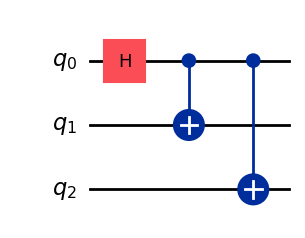

In [41]:
# Create a 3-qubit GHZ circuit
ghz3 = create_ghz_circuit(3)

# Draw the circuit diagram
ghz3.draw("mpl")

In [42]:
# ------------------------------------------------------------
# Create the initial quantum state |000>
# 3 qubits = 8 basis states
# ------------------------------------------------------------
state = Statevector.from_int(0, 2 ** 3)

# Apply the GHZ circuit
state = state.evolve(ghz3)

# Display the resulting GHZ state
state.draw("latex")

<IPython.core.display.Latex object>

In [43]:
# ------------------------------------------------------------
# Function to simulate GHZ states with measurement
# ------------------------------------------------------------
def simulate_ghz(n, shots=1024):

    # Create a circuit with:
    # n qubits
    # n classical bits
    circuit = QuantumCircuit(n, n)

    # --------------------------------------------------------
    # Put qubit 0 into superposition
    # --------------------------------------------------------
    circuit.h(0)

    # --------------------------------------------------------
    # Entangle all qubits
    # --------------------------------------------------------
    for i in range(1, n):

        # Apply CNOT gates
        circuit.cx(0, i)

    # --------------------------------------------------------
    # Measure all qubits
    # --------------------------------------------------------
    circuit.measure(range(n), range(n))

    # Compile the circuit
    qc_compiled = transpile(circuit, backend)

    # Run the simulation
    job_sim = backend.run(qc_compiled, shots=shots)

    # Get the results
    result_sim = job_sim.result()

    # Count the outcomes
    counts = result_sim.get_counts(qc_compiled)

    # Print the measurement counts
    print(counts)

    # Display histogram
    display(plot_histogram(counts))

    # Return the circuit
    return circuit

{'000': 496, '111': 528}


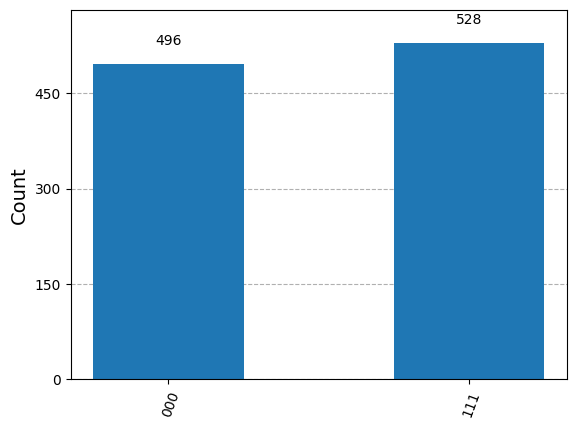

{'0000': 528, '1111': 496}


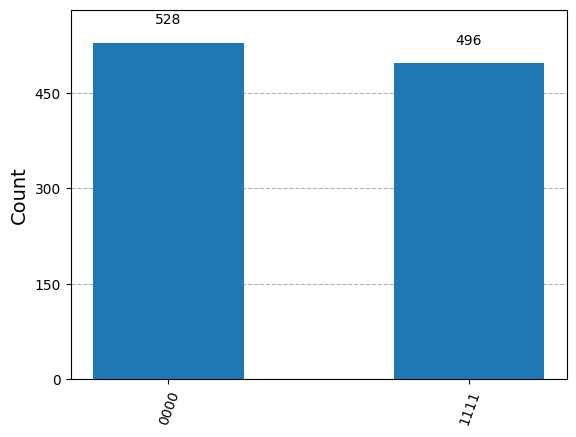

{'11111': 523, '00000': 501}


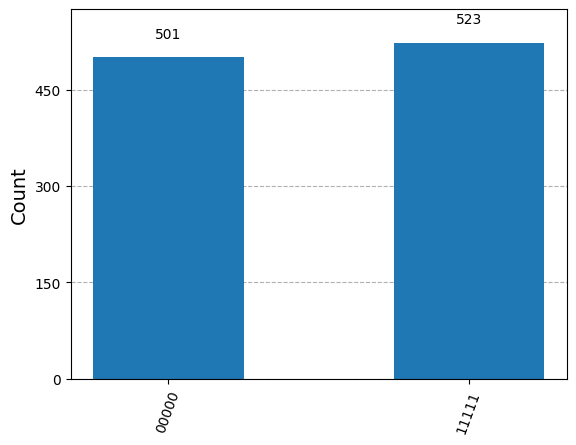

{'0000000000': 509, '1111111111': 515}


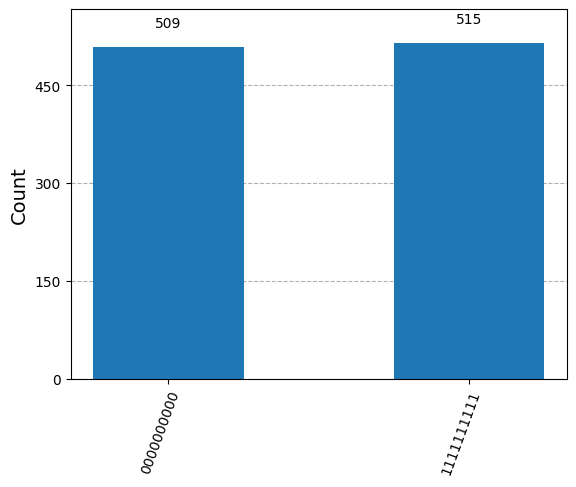

In [44]:
# Simulate a 3-qubit GHZ state
simulate_ghz(3)
# Simulate a 4-qubit GHZ state
simulate_ghz(4)
# Simulate a 5-qubit GHZ state
simulate_ghz(5)
# Simulate a 10-qubit GHZ state
simulate_ghz(10)